<a href="https://colab.research.google.com/github/john2004vincent/Data-Science-Coursework-1/blob/main/Decision_Tree_on_Processed_Fish_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Processed_fresh_fish.csv')
df.head()

,Unnamed: 0,area,equivalent_diameter,mean_intensity,solidity,axis_major_length,axis_minor_length,name,area_sqs_microns,equivalent_dimater_microns,elongation,perimeter,eccentricity,circularity
0,0,[174396],[69.31799075],[126.31101057],[0.89343129],[508.45107213],[3.65148372],Red Sea Bream,[62782.56],[41.59079445],[0.00718158],[2026.77823372],[0.99997421],[0.53349938]
1,1,[166623],[68.27244282],[129.83271817],[0.91844294],[395.23648293],[3.65148372],Red Sea Bream,[59984.28],[40.96346569],[0.00923873],[1575.83687957],[0.99995732],[0.84318388]
2,2,[225834],[75.55506233],[139.22421779],[0.88161994],[597.40458587],[3.65148372],Red Sea Bream,[81300.24],[45.3330374],[0.00611225],[2381.09539397],[0.99998132],[0.50054785]
3,3,[141540],[64.65868328],[126.44652395],[0.89134911],[447.57372841],[3.65148372],Red Sea Bream,[50954.4],[38.79520997],[0.0081584],[1784.29746885],[0.99996672],[0.55866895]
4,4,[216615],[74.51264299],[125.99433096],[0.88656009],[567.8136576],[3.65148372],Red Sea Bream,[77981.4],[44.70758579],[0.00643078],[2263.22899629],[0.99997932],[0.53142428]


In [ ]:
#drop index column
df = df.drop(columns=['Unnamed: 0'])
df.head()

,area,equivalent_diameter,mean_intensity,solidity,axis_major_length,axis_minor_length,name,area_sqs_microns,equivalent_dimater_microns,elongation,perimeter,eccentricity,circularity
0,[174396],[69.31799075],[126.31101057],[0.89343129],[508.45107213],[3.65148372],Red Sea Bream,[62782.56],[41.59079445],[0.00718158],[2026.77823372],[0.99997421],[0.53349938]
1,[166623],[68.27244282],[129.83271817],[0.91844294],[395.23648293],[3.65148372],Red Sea Bream,[59984.28],[40.96346569],[0.00923873],[1575.83687957],[0.99995732],[0.84318388]
2,[225834],[75.55506233],[139.22421779],[0.88161994],[597.40458587],[3.65148372],Red Sea Bream,[81300.24],[45.3330374],[0.00611225],[2381.09539397],[0.99998132],[0.50054785]
3,[141540],[64.65868328],[126.44652395],[0.89134911],[447.57372841],[3.65148372],Red Sea Bream,[50954.4],[38.79520997],[0.0081584],[1784.29746885],[0.99996672],[0.55866895]
4,[216615],[74.51264299],[125.99433096],[0.88656009],[567.8136576],[3.65148372],Red Sea Bream,[77981.4],[44.70758579],[0.00643078],[2263.22899629],[0.99997932],[0.53142428]


In [ ]:
#check data types
print(df.dtypes)

area                          object
equivalent_diameter           object
mean_intensity                object
solidity                      object
axis_major_length             object
axis_minor_length             object
name                          object
area_sqs_microns              object
equivalent_dimater_microns    object
elongation                    object
perimeter                     object
eccentricity                  object
circularity                   object
dtype: object


In [ ]:
#convert name to string
df['name'] = df['name'].astype(str)

#convert other columns to float
columns_to_float = [
    'area', 'equivalent_diameter', 'mean_intensity', 'solidity',
    'axis_major_length', 'axis_minor_length', 'area_sqs_microns',
    'equivalent_dimater_microns', 'elongation', 'perimeter',
    'eccentricity', 'circularity'
]

#remove []
import re
def clean(value):
    return re.sub(r'[^\d.-]', '', value)

for col in columns_to_float:
  df[col] = df[col].apply(clean).astype(float)

print(df.dtypes)

area                          float64
equivalent_diameter           float64
mean_intensity                float64
solidity                      float64
axis_major_length             float64
axis_minor_length             float64
name                           object
area_sqs_microns              float64
equivalent_dimater_microns    float64
elongation                    float64
perimeter                     float64
eccentricity                  float64
circularity                   float64
dtype: object


In [ ]:
#separate features (X) from target (y)
X = df.drop(columns=['name'])
y = df['name']

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

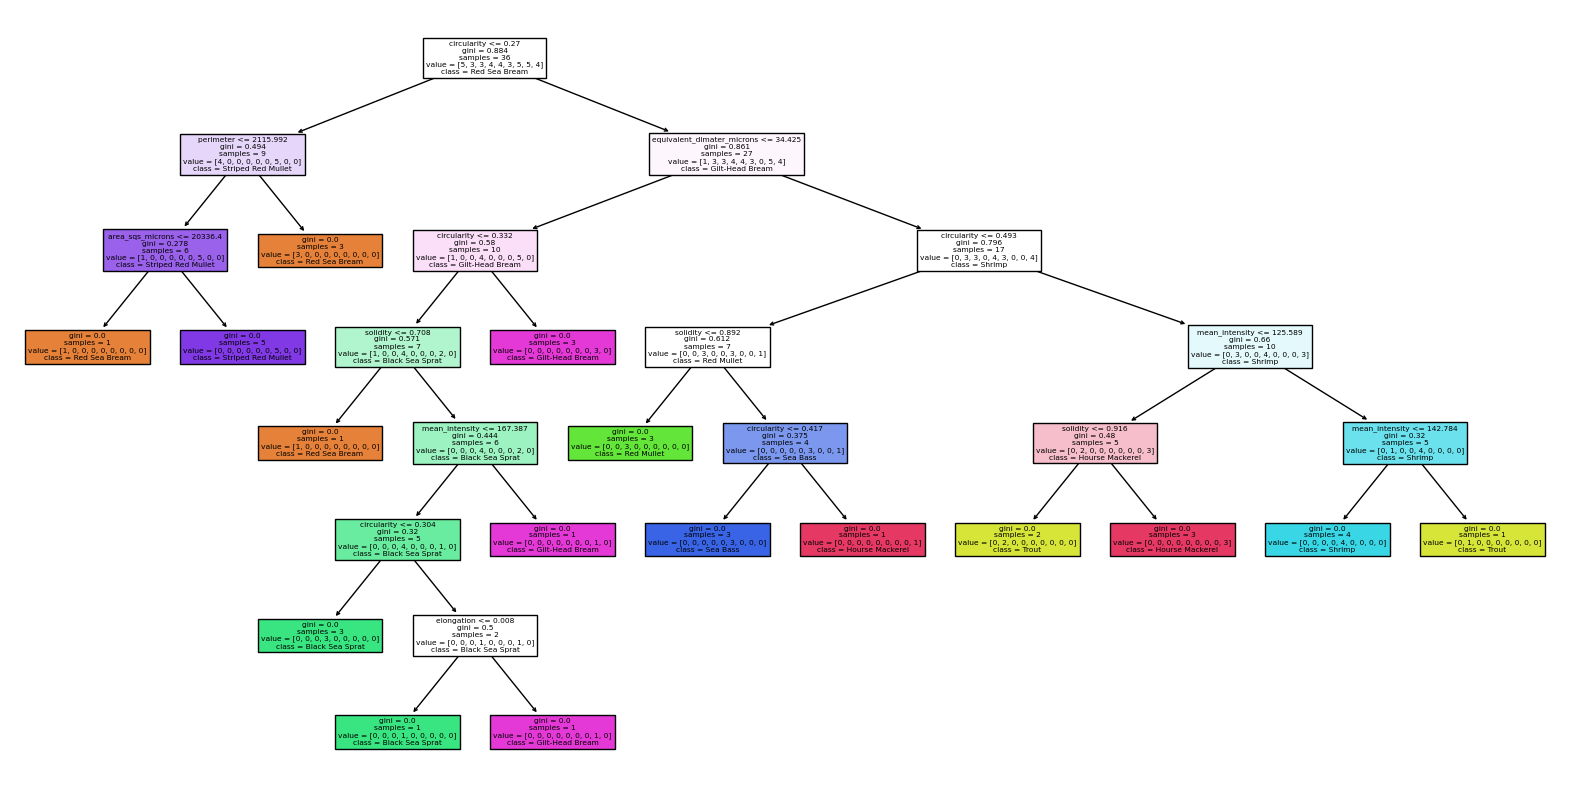

Accuracy: 0.36
Precision: 0.39
Recall: 0.36


In [ ]:
#create decision tree classifier with gini index attribute criterion
dtc = DecisionTreeClassifier(criterion='gini')

#split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#fit
dtc.fit(X_train, y_train)

#predict
dtc.predict(X_test)

#visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=X.columns, class_names=df['name'].unique())
plt.show()

#apply
predictions = dtc.predict(X_test)

#define 5-fold cross-validation object
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#apply
predictions_cv = cross_val_predict(dtc, X, y, cv=kf)

#compute metrics
accuracy = accuracy_score(y, predictions_cv)
precision = precision_score(y, predictions_cv, average='weighted', zero_division=0)
recall = recall_score(y, predictions_cv, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")